In [2]:
import pandas as pd
import numpy as np
import os
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)
print("✅ Library successfully imported!")

TensorFlow version: 2.21.0
✅ Library successfully imported!


In [3]:
# Load train, val, test dataset
train_df = pd.read_csv('../train_dataset.csv')
val_df = pd.read_csv('../val_dataset.csv')
test_df = pd.read_csv('../test_dataset.csv')

print(f"Train: {len(train_df)} images")
print(f"Val: {len(val_df)} images")
print(f"Test: {len(test_df)} images")

Train: 619 images
Val: 165 images
Test: 217 images


In [4]:
# Fungsi untuk load gambar dari folder
def load_images(dataframe, image_folder='../Images_augmented'):
    images = []
    labels = []
    
    total = len(dataframe)
    for i, (index, row) in enumerate(dataframe.iterrows()):
        img_path = os.path.join(image_folder, row['Image Name'])
        
        if os.path.exists(img_path):
            img = Image.open(img_path).convert('RGB')
            img = img.resize((224, 224))
            img_array = np.array(img) / 255.0
            images.append(img_array)
            labels.append(row['label_numeric'])
        
        if (i + 1) % 100 == 0:
            print(f"Progress: {i+1}/{total}")
    
    return np.array(images), np.array(labels)

# Load semua data
print("Loading train data...")
X_train, y_train = load_images(train_df)

print("\nLoading val data...")
X_val, y_val = load_images(val_df)

print("\nLoading test data...")
X_test, y_test = load_images(test_df)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print("\n✅ All data loaded successfully!")

Loading train data...
Progress: 100/619
Progress: 200/619
Progress: 300/619
Progress: 400/619
Progress: 500/619
Progress: 600/619

Loading val data...
Progress: 100/165

Loading test data...
Progress: 100/217
Progress: 200/217

X_train shape: (619, 224, 224, 3)
X_val shape: (165, 224, 224, 3)
X_test shape: (217, 224, 224, 3)

✅ All data loaded successfully!


BUILD CNN


In [5]:
# Build CNN Model
model = models.Sequential()

# Convolutional Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D((2,2)))

# Convolutional Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Convolutional Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Fully Connected Layer
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/home/ahmad/Documents/IDSC2026/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1774656045.019648   15983 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '../glaucoma_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train model
print("Training start...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint]
)

print("\n✅ Training completed!")

Training start...
Epoch 1/10


W0000 00:00:1774656046.458181   15983 cpu_allocator_impl.cc:82] Allocation of 372707328 exceeds 10% of free system memory.
W0000 00:00:1774656049.082761   20307 cpu_allocator_impl.cc:82] Allocation of 201867264 exceeds 10% of free system memory.
W0000 00:00:1774656049.322943   20303 cpu_allocator_impl.cc:82] Allocation of 97329152 exceeds 10% of free system memory.
W0000 00:00:1774656050.271328   20306 cpu_allocator_impl.cc:82] Allocation of 97329152 exceeds 10% of free system memory.
W0000 00:00:1774656050.854544   20307 cpu_allocator_impl.cc:82] Allocation of 100933632 exceeds 10% of free system memory.


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5347 - loss: 0.8903
Epoch 1: val_accuracy improved from None to 0.78182, saving model to ../glaucoma_model.keras

Epoch 1: finished saving model to ../glaucoma_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.5767 - loss: 0.7679 - val_accuracy: 0.7818 - val_loss: 0.6129
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7548 - loss: 0.5360
Epoch 2: val_accuracy improved from 0.78182 to 0.94545, saving model to ../glaucoma_model.keras

Epoch 2: finished saving model to ../glaucoma_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8061 - loss: 0.4597 - val_accuracy: 0.9455 - val_loss: 0.2245
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8990 - loss: 0.2833
Epoch 3: val_accuracy did not improve from 0.94545
20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9225 - loss: 0.2272 - val_accuracy: 0.9394 - val_loss: 0.1879
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy

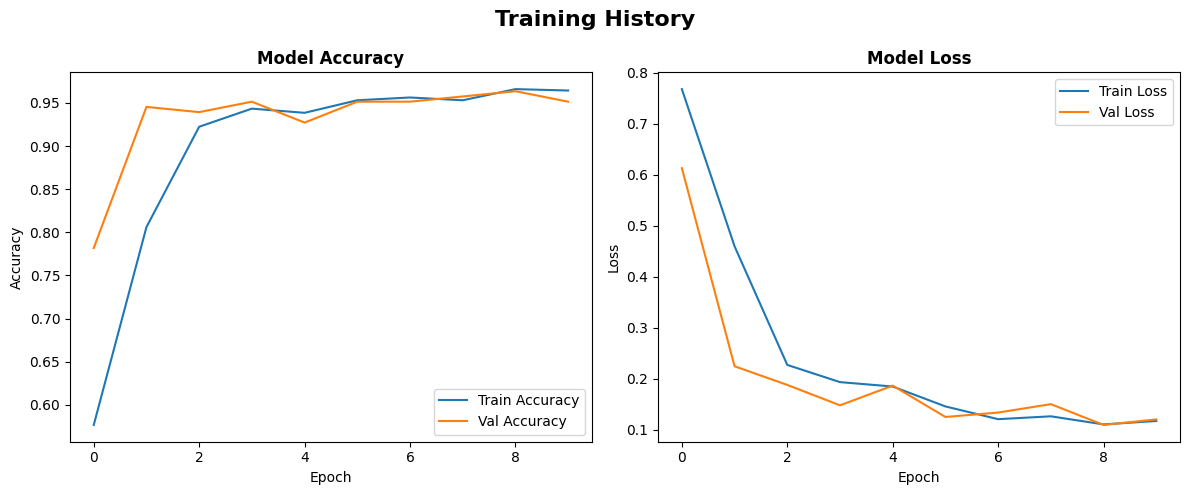

✅ Training history saved!


In [7]:
import matplotlib.pyplot as plt

# Plot accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training history saved!")

Model konvergen dengan baik dalam 10 epoch, mencapai val accuracy 95.76% tanpa tanda overfitting, terlihat dari train dan val loss yang turun bersamaan